# La stratégie adaptée — partir du portefeuille d'entrée, et des trades O/A/T (House)

**L'idée** (cf. `FICHE_10_CHRONOLOGIE.pdf`) : la stratégie de copy-trading reconstruisait chaque
portefeuille **à partir de zéro** et ne lisait que les PTR. Ici, House uniquement :

| étape | quoi |
|---|---|
| É1 | les données, chacune prouvée (sha256, re-preuves) |
| É2 | le flux de trades : PTR ∪ O/A/T, provenance tracée |
| É3 | la population : 900 → 424 qui tradent → avec / sans photo d'entrée |
| É4 | les règles : G_zéro part de zéro · G_photo part de sa photo (h₀ au jour du dépôt) |
| É5 | le moteur en parts (défini et validé ici) et les 4 runs A/B/C/D |
| É6 | la stratégie la plus simple : Sharpe · K walk-forward · deux poids |
| É7 | le mélange G_photo / G_zéro : surveillé (S1), contrôlé (S2) |
| É8 | lecture |

**Notebook indépendant** : inspiré du 05b, mais chaque brique est redéfinie et re-validée ICI
(recalcul naïf, propriétés testées numériquement, recoupements). Seuls acquis : les tables
nettoyées (S1/S2 et v1-house) et les caches de prix.
**Anti-triche** : une information n'existe qu'à partir de la date de **dépôt** du document qui la porte.

## É1 — Les données, chacune prouvée

Cinq entrées : la table clean S1/S2 (transactions PTR) ; trois tables v1-house — photos d'entrée
(15), holdings des photos (11), trades O/A/T sans écho PTR (16) — plus le registre des 900 (14) ;
et les prix (`prices_v2`, jamais modifié + `prices_holdings_v1`, cache séparé).

In [1]:
import pandas as pd, numpy as np, hashlib, json, os, glob
import matplotlib.pyplot as plt

J     = "/Users/lemairealice/Downloads/Jupiter"
BASE  = os.path.join(J, "02_recherche_backtest")
V1T   = os.path.join(J, "01_autres_filing_types", "cache", "tables")
CLEAN = os.path.join(J, "00_recuperation_donnees", "data", "clean", "transactions_backtest_2014_2026.csv")
MAN   = json.load(open(os.path.join(J, "01_autres_filing_types", "cache", "MANIFEST.json")))

for _f in ["11_holdings_complets.csv", "14_registre_membres.csv",
           "15_portefeuille_entree.csv", "16_flux_oat_net.csv"]:
    _h = hashlib.sha256(open(os.path.join(V1T, _f), "rb").read()).hexdigest()
    assert _h == MAN["sha_tables"][_f], f"sha divergent : {_f}"
print("4 tables v1-house conformes au MANIFEST (sha256) — leur provenance est prouvée, pas supposée")

4 tables v1-house conformes au MANIFEST (sha256) — leur provenance est prouvée, pas supposée


**La table clean** (S1/S2) : une ligne = une transaction PTR. On ne lit que les colonnes utiles.

In [2]:
cl = pd.read_csv(CLEAN, low_memory=False,
                 usecols=["bioguide_id", "member_name", "chamber", "ticker", "ticker_yahoo",
                          "direction", "transaction_date", "amount_midpoint", "amount_range"],
                 parse_dates=["transaction_date"])
print(f"clean — {cl.shape[0]:,} lignes × {cl.shape[1]} colonnes | "
      f"chambres : {dict(cl['chamber'].value_counts())}")
display(cl.head(3))

clean — 134,464 lignes × 9 colonnes | chambres : {'house': np.int64(122814), 'senate': np.int64(11650)}


,bioguide_id,member_name,chamber,ticker,ticker_yahoo,direction,amount_midpoint,amount_range,transaction_date
0,G000563,Bob Gibbs,house,INTC,INTC,buy,8000.5,"$1,001 - $15,000",2014-12-30
1,G000563,Bob Gibbs,house,B,B,sell,8000.5,"$1,001 - $15,000",2014-12-23
2,G000563,Bob Gibbs,house,AAPL,AAPL,buy,8000.5,"$1,001 - $15,000",2014-12-30


In [3]:
e15  = pd.read_csv(os.path.join(V1T, "15_portefeuille_entree.csv"), parse_dates=["filing_date"])
h11  = pd.read_csv(os.path.join(V1T, "11_holdings_complets.csv"), low_memory=False,
                   usecols=["doc_id", "bioguide", "ticker", "value_lo", "value_hi", "conteneur_nu"])
f16  = pd.read_csv(os.path.join(V1T, "16_flux_oat_net.csv"), low_memory=False,
                   parse_dates=["transaction_date", "disclosure_date"])
reg14 = pd.read_csv(os.path.join(V1T, "14_registre_membres.csv"))
for _nom, _t in [("15_portefeuille_entree (photos d'entrée)", e15),
                 ("11_holdings_complets (contenu des photos)", h11),
                 ("16_flux_oat_net (trades O/A/T sans écho PTR)", f16),
                 ("14_registre_membres (les 900)", reg14)]:
    print(f"{_nom} — {_t.shape[0]:,} × {_t.shape[1]}")
    display(_t.head(3))

15_portefeuille_entree (photos d'entrée) — 284 × 7


,bioguide,doc_id,type_photo,filing_date,n_tickers,delta_jours_mandat,garde_fous_ok
0,A000148,10040680,H,2021-07-29,27,NaN,True
1,A000373,10005854,H,2015-05-14,83,NaN,True
2,A000375,10009542,C,2016-02-13,2,325.0,True


11_holdings_complets (contenu des photos) — 420,916 × 6


,ticker,value_lo,value_hi,doc_id,conteneur_nu,bioguide
0,NaN,15001,50000.0,10023848,False,A000374
1,NaN,1000001,5000000.0,10023848,False,A000374
2,NaN,50001,100000.0,10023848,False,A000374


16_flux_oat_net (trades O/A/T sans écho PTR) — 26,115 × 28


,doc_id,provenance,filing_type,annee_index,bioguide,declarant_name,state_district,transaction_date,transaction_date_brute,disclosure_date,...,amount_mid,amount_mid_conventionnel,amount_reconstruit,amount_exact,cle_naturelle,occurrence_index,n_docs_vus,source,sens,echo_ptr
0,10004256,fd_T,T,2014,C001046,Eric Ivan Cantor,VA07,2014-01-16,01/16/2014,2014-09-15,...,8000.5,8000.5,False,False,"C001046|01/16/2014|LEO|P|$1,001 - $15,000|SELF",0,1,instantane_seul,P,False
1,10004256,fd_T,T,2014,C001046,Eric Ivan Cantor,VA07,2014-01-31,01/31/2014,2014-09-15,...,75000.5,75000.5,False,False,"C001046|01/31/2014|LEO|S|$50,001 - $100,000|SELF",0,1,instantane_seul,S,False
2,10004256,fd_T,T,2014,C001046,Eric Ivan Cantor,VA07,2014-01-16,01/16/2014,2014-09-15,...,8000.5,8000.5,False,False,"C001046|01/16/2014|MOO|P|$1,001 - $15,000|SELF",0,1,instantane_seul,P,False


14_registre_membres (les 900) — 900 × 10


,bioguide,categorie,quadrant,n_photos,a_flux,a_photo_entree,dans_cohorte_Ca,dans_cohorte_papier,premiere_photo,derniere_photo
0,C001087,hors d'atteinte,déjà-là restés,0,False,False,False,False,NaN,NaN
1,C001095,hors d'atteinte,déjà-là partis,0,False,False,False,False,NaN,NaN
2,C001131,hors d'atteinte,arrivés restés,0,False,False,False,False,NaN,NaN


**Tickers.** Map m : `ticker` → `ticker_yahoo`, **reconstruite** depuis la table clean
(0 constante héritée) ; défaut m(t) = t avec « . » → « - ».

In [4]:
_paires = cl[["ticker", "ticker_yahoo"]].dropna().drop_duplicates()
assert (_paires.groupby("ticker")["ticker_yahoo"].nunique() <= 1).all(), "map ambiguë"
MAP_YAHOO = dict(zip(_paires["ticker"], _paires["ticker_yahoo"]))
def to_yahoo(t):
    t = str(t)
    return MAP_YAHOO.get(t, t.replace(".", "-"))
print(f"map : {len(MAP_YAHOO)} paires, {sum(1 for k, v in MAP_YAHOO.items() if k != v)} renommages, 0 conflit")
display(_paires[_paires["ticker"] != _paires["ticker_yahoo"]].head(3))

map : 4653 paires, 52 renommages, 0 conflit


,ticker,ticker_yahoo
217,CTL,LUMN
255,DISCA,WBD
260,FB,META


**Fourchettes.** Un montant déclaré est une fourchette [v̲, v̄] ; on travaille au milieu
ṽ = (v̲+v̄)/2. Re-preuve : les milieux v1 ≡ ceux de la table clean sur toutes les fourchettes communes.

In [5]:
_g_clean = (cl.dropna(subset=["amount_range", "amount_midpoint"])
            .groupby("amount_range")["amount_midpoint"].first())
_v1_mid = (f16.assign(mid=(f16["amount_lo"] + f16["amount_hi"]) / 2)
           .groupby("amount_range")["mid"].first())
_commun = _g_clean.index.intersection(_v1_mid.index)
assert (_g_clean.loc[_commun] - _v1_mid.loc[_commun]).abs().max() == 0
print(f"{len(_commun)} fourchettes communes, écart max des milieux = 0 ✅")
display(pd.DataFrame({"midpoint_clean": _g_clean.loc[_commun], "mid_v1": _v1_mid.loc[_commun]}).head(4))

12 fourchettes communes, écart max des milieux = 0 ✅


,midpoint_clean,mid_v1
amount_range,,
"$1,000,001 - $5,000,000",3000000.5,3000000.5
"$1,001 - $15,000",8000.5,8000.5
"$100,001 - $250,000",175000.5,175000.5
$121,121.0,121.0


**Les transactions House.** F_ptr = la table clean restreinte à la House, fenêtre 2013-2026,
au format du moteur : (membre, ticker, sens, date de transaction, ṽ).

In [6]:
df = (cl[cl["chamber"] == "house"]
      .drop(columns=["ticker"])
      .rename(columns={"member_name": "name", "ticker_yahoo": "ticker", "direction": "op",
                       "transaction_date": "traded", "amount_midpoint": "size_usd"}))
_n0 = len(df)
df = df[df["traded"].dt.year.between(2013, 2026)]
df = df[["bioguide_id", "name", "ticker", "op", "traded", "size_usd"]].reset_index(drop=True)
print(f"House : {_n0:,} lignes clean → {len(df):,} dans la fenêtre 2013-2026 "
      f"| {df['bioguide_id'].nunique()} membres | {df['ticker'].nunique():,} tickers")
display(df.head(3))

House : 122,814 lignes clean → 122,809 dans la fenêtre 2013-2026 | 315 membres | 4,340 tickers


,bioguide_id,name,ticker,op,traded,size_usd
0,G000563,Bob Gibbs,INTC,buy,2014-12-30,8000.5
1,G000563,Bob Gibbs,B,sell,2014-12-23,8000.5
2,G000563,Bob Gibbs,AAPL,buy,2014-12-30,8000.5


**Le contenu des photos d'entrée.** Jointure 15 ⋈ 11 par `doc_id`, lignes tickérisées et
valorisées seulement, ticker → yahoo, milieux sommés par (membre, ticker).

In [7]:
_perdus = sorted(set(e15["doc_id"]) - set(h11["doc_id"]))
assert _perdus == [10041638]        # 1 photo H à 1 ticker absente de la table 11 — journalisée
ph_ent = (e15.merge(h11, on="doc_id", suffixes=("", "_h"))
             .query("ticker == ticker and ~conteneur_nu")
             .assign(mid=lambda d: (d["value_lo"] + d["value_hi"]) / 2)
             .dropna(subset=["mid"]))
ph_ent["ticker_y"] = ph_ent["ticker"].map(to_yahoo)
ph_ent = ph_ent.groupby(["bioguide", "ticker_y", "filing_date"], as_index=False)["mid"].sum()
print(f"photos exploitables : {ph_ent['bioguide'].nunique()} membres · {len(ph_ent):,} lignes "
      f"· {ph_ent['mid'].sum()/1e6:,.0f} M$ (doc perdu journalisé : {_perdus})")
display(ph_ent.head(3))

photos exploitables : 248 membres · 9,310 lignes · 792 M$ (doc perdu journalisé : [10041638])


,bioguide,ticker_y,filing_date,mid
0,A000148,ARAIX,2021-07-29,32500.5
1,A000148,CSVIX,2021-07-29,8000.5
2,A000148,CTTIX,2021-07-29,65001.0


**Les prix.** Calendrier maître = SPY. Univers = tickers des trades House ∪ tickers des photos ;
sources : `prices_v2` (prioritaire, jamais modifié) puis `prices_holdings_v1` (cache séparé,
resumable : complet ⇒ 0 téléchargement). Garde-fou anti-corruption : série < 2 points,
prix < 0,10 $ ou saut > 300 %/jour ⇒ exclue.

In [8]:
PRICES_V2   = os.path.join(BASE, "cache", "prices_v2")
PRICES_HOLD = os.path.join(BASE, "cache", "prices_holdings_v1")
_SNAP_PV2 = sorted(os.listdir(PRICES_V2))                    # re-asserté en toute fin
spy = (pd.read_csv(os.path.join(PRICES_V2, "SPY.csv"), parse_dates=["Date"])
         .set_index("Date")["close"].sort_index())
cal = spy.index
r_spy = spy.pct_change()
print(f"calendrier : {len(cal)} jours cotés, {cal[0].date()} → {cal[-1].date()} | snapshot prices_v2 : {len(_SNAP_PV2)} fichiers")

calendrier : 3645 jours cotés, 2012-01-03 → 2026-07-02 | snapshot prices_v2 : 3351 fichiers


In [9]:
# univers COMPLET : tickers des trades PTR ∪ photos ∪ trades O/A/T (v7 — avant, les tickers
# oat-only n'étaient ni chargés ni téléchargés : des trades O/A/T étaient écartés à tort)
_univers = (set(df["ticker"].dropna()) | set(ph_ent["ticker_y"])
            | set(f16["ticker"].dropna().map(to_yahoo)))
_have_v2 = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES_V2, "*.csv"))} - {"failed_v2"}
_have_ph = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES_HOLD, "*.csv"))} - {"failed_holdings_v1"}
_fail_f  = os.path.join(PRICES_HOLD, "failed_holdings_v1.csv")
_failed  = set(pd.read_csv(_fail_f)["ticker"]) if os.path.exists(_fail_f) else set()
_todo    = sorted(_univers - _have_v2 - _have_ph - _failed)
print(f"univers : {len(_univers):,} tickers | v2 : {len(_univers & _have_v2):,} | cache séparé : "
      f"{len(_univers & _have_ph):,} | échecs connus : {len(_univers & _failed):,} | à télécharger : {len(_todo)}")
if _todo:                                                    # resumable — cache complet => jamais exécuté
    import yfinance as yf, logging
    logging.getLogger("yfinance").setLevel(logging.CRITICAL)
    _new_fail = []
    for _i in range(0, len(_todo), 60):
        _chunk = _todo[_i:_i + 60]
        try:
            _data = yf.download(_chunk, start="2012-01-01", end="2026-07-03", auto_adjust=True,
                                progress=False, threads=True, group_by="ticker")
        except Exception:
            _data = None
        for _t in _chunk:
            _s = None
            try:
                if _data is not None and isinstance(_data.columns, pd.MultiIndex):
                    if _t in _data.columns.get_level_values(0):
                        _s = _data[_t]["Close"].dropna()
            except Exception:
                _s = None
            if _s is not None and len(_s) >= 2:
                _s.rename("close").to_csv(os.path.join(PRICES_HOLD, _t + ".csv"), index_label="Date")
            else:
                _new_fail.append(_t)
    if _new_fail:
        _old = pd.read_csv(_fail_f) if os.path.exists(_fail_f) else pd.DataFrame(columns=["ticker"])
        pd.concat([_old, pd.DataFrame({"ticker": _new_fail})]).drop_duplicates().to_csv(_fail_f, index=False)
    _have_ph = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES_HOLD, "*.csv"))} - {"failed_holdings_v1"}

univers : 7,600 tickers | v2 : 3,214 | cache séparé : 2,336 | échecs connus : 2,050 | à télécharger : 0


In [10]:
prices, _corrompus = {}, []
for _tk in sorted(_univers):
    _p = (os.path.join(PRICES_V2, _tk + ".csv") if _tk in _have_v2
          else os.path.join(PRICES_HOLD, _tk + ".csv") if _tk in _have_ph else None)
    if _p is None:
        continue
    _s = pd.read_csv(_p, parse_dates=["Date"]).set_index("Date")["close"].sort_index().reindex(cal).ffill()
    if (len(_s.dropna()) < 2 or _s.dropna().min() < 0.10
            or _s.dropna().pct_change().abs().max() > 3.0):
        _corrompus.append(_tk); continue
    prices[_tk] = _s
_n_avant = len(df)
df = df[df["ticker"].isin(prices)].reset_index(drop=True)
print(f"prix chargés : {len(prices):,} tickers ({len(_corrompus)} corrompus exclus) | "
      f"trades House : {_n_avant:,} → {len(df):,} avec prix (−{_n_avant-len(df):,}) | "
      f"{df['bioguide_id'].nunique()} membres")

prix chargés : 5,476 tickers (74 corrompus exclus) | trades House : 122,809 → 107,976 avec prix (−14,833) | 305 membres


### É1.1 Validation
Sha 4/4 · fourchettes clean ≡ v1 (écart 0) · map tickers 0 conflit · doc perdu journalisé ·
calendrier SPY complet · tout trade retenu a un prix exploitable.

In [11]:
assert df["ticker"].isin(prices).all() and df["op"].isin(["buy", "sell", "exchange"]).all()
assert df["traded"].dt.year.between(2013, 2026).all() and (df["size_usd"] > 0).all()
df = df[df["op"] != "exchange"].reset_index(drop=True)     # pas de sens directionnel — écartés, comptés
print(f"✅ É1 valide — {len(df):,} trades House exploitables (les 'exchange' écartés)")

✅ É1 valide — 107,976 trades House exploitables (les 'exchange' écartés)


## É2 — Le flux de trades : PTR ∪ les trades que seuls les rapports O/A/T contiennent

La table 16 (v1) = trades des Schedule B annuels/terminaisons/amendements **sans écho PTR à
±365 j**. On les met au format du moteur, on retire ce qui n'est pas jouable, et chaque trade
garde sa `provenance`. Convention de date : la **date de transaction** (celle du moteur).

In [12]:
df_oat = f16.rename(columns={"bioguide": "bioguide_id", "declarant_name": "name",
                             "transaction_date": "traded",
                             "amount_mid_conventionnel": "size_usd"}).copy()
df_oat["ticker"] = df_oat["ticker"].map(to_yahoo)
df_oat["op"] = df_oat["sens"].map({"P": "buy", "S": "sell"})
_n0 = len(df_oat)
df_oat = df_oat.dropna(subset=["op"])                              # 'E' (exchange) : écartés
_n1 = len(df_oat)
df_oat = df_oat[df_oat["traded"].dt.year.between(2013, 2026)]      # dates corrompues dehors
_n2 = len(df_oat)
df_oat = df_oat[df_oat["size_usd"].notna() & (df_oat["size_usd"] > 0)]
_n3 = len(df_oat)
df_oat = df_oat[df_oat["ticker"].isin(prices)]
df_oat = df_oat[["bioguide_id", "name", "ticker", "op", "traded", "size_usd"]].assign(provenance="oat")
print(f"O/A/T : {_n0:,} → {_n1:,} (−{_n0-_n1} exchanges) → {_n2:,} (−{_n1-_n2} dates hors fenêtre) "
      f"→ {_n3:,} (−{_n2-_n3} sans montant) → {len(df_oat):,} avec prix (−{_n3-len(df_oat):,})")
display(df_oat.head(3))

O/A/T : 26,115 → 25,894 (−221 exchanges) → 25,880 (−14 dates hors fenêtre) → 25,880 (−0 sans montant) → 21,465 avec prix (−4,415)


,bioguide_id,name,ticker,op,traded,size_usd,provenance
0,C001046,Eric Ivan Cantor,LEO,buy,2014-01-16,8000.5,oat
1,C001046,Eric Ivan Cantor,LEO,sell,2014-01-31,75000.5,oat
2,C001046,Eric Ivan Cantor,MOO,buy,2014-01-16,8000.5,oat


**Doublons inter-sources.** La table 16 est nette côté v1 ; on re-vérifie contre NOTRE F_ptr :
collision exacte = même (membre, ticker, sens, date). Retirées et comptées.

In [13]:
_cle = ["bioguide_id", "ticker", "op", "traded"]
_coll = df_oat.merge(df[_cle], on=_cle, how="inner")
print(f"collisions exactes F_oat × F_ptr : {len(_coll)} ({len(_coll)/max(len(df_oat),1)*100:.2f} %) — retirées")
if len(_coll):
    df_oat = (df_oat.merge(_coll[_cle].drop_duplicates(), on=_cle, how="left", indicator=True)
                    .query("_merge == 'left_only'").drop(columns="_merge"))
assert len(df_oat.merge(df[_cle], on=_cle, how="inner")) == 0
df_uni = pd.concat([df.assign(provenance="ptr"), df_oat], ignore_index=True)
print(f"F = {len(df_uni):,} trades = {int((df_uni['provenance']=='ptr').sum()):,} ptr + "
      f"{int((df_uni['provenance']=='oat').sum()):,} oat | membres : {df_uni['bioguide_id'].nunique()}")
display(df_uni.groupby("provenance").head(2).sort_values("provenance"))

collisions exactes F_oat × F_ptr : 490 (2.28 %) — retirées
F = 128,960 trades = 107,976 ptr + 20,984 oat | membres : 437


,bioguide_id,name,ticker,op,traded,size_usd,provenance
107976,C001046,Eric Ivan Cantor,LEO,buy,2014-01-16,8000.5,oat
107977,C001046,Eric Ivan Cantor,LEO,sell,2014-01-31,75000.5,oat
0,G000563,Bob Gibbs,INTC,buy,2014-12-30,8000.5,ptr
1,G000563,Bob Gibbs,B,sell,2014-12-23,8000.5,ptr


In [14]:
# LIVRE DE COMPTES O/A/T — chaque ligne écartée a une raison, et une seule (asserts)
_lc = f16.rename(columns={"bioguide": "bioguide_id", "transaction_date": "traded"}).copy()
_lc["ty"] = _lc["ticker"].map(to_yahoo)
_lc["op"] = _lc["sens"].map({"P": "buy", "S": "sell"})
_r_exch = _lc["op"].isna()
_r_date = ~_r_exch & ~_lc["traded"].dt.year.between(2013, 2026)
_r_mont = ~_r_exch & ~_r_date & ~(_lc["amount_mid_conventionnel"] > 0)
_avant  = ~(_r_exch | _r_date | _r_mont)
_r_corr = _avant & _lc["ty"].isin(_corrompus)
_r_prix = _avant & ~_r_corr & ~_lc["ty"].isin(prices)
_okm    = _avant & ~_r_corr & ~_r_prix
_k = ["bioguide_id", "ty", "op", "traded"]
_cles_ptr = df.rename(columns={"ticker": "ty"})[_k]
_hit = _lc[_okm].merge(_cles_ptr.drop_duplicates().assign(_h=1), on=_k, how="left")["_h"].notna()
_n_coll_lignes = int(_hit.sum())
_n_appar = len(_lc[_okm].merge(_cles_ptr, on=_k, how="inner"))
_n_ok = int(_okm.sum()) - _n_coll_lignes
livre_oat = pd.DataFrame([
    ("lignes table 16 (trades O/A/T sans écho PTR côté v1)", len(_lc), ""),
    ("− exchanges (sens E : ni achat ni vente)", -int(_r_exch.sum()), ""),
    ("− date hors fenêtre 2013-2026 (dates corrompues)", -int(_r_date.sum()), ""),
    ("− sans montant exploitable", -int(_r_mont.sum()), ""),
    ("− ticker corrompu (garde-fou prix)", -int(_r_corr.sum()), ""),
    ("− aucune série de prix (après tentative de téléchargement)", -int(_r_prix.sum()),
     "fonds monétaires/OTC en tête"),
    ("− en collision exacte avec un PTR de NOTRE table", -_n_coll_lignes,
     f"{_n_appar} appariements ({_n_appar - _n_coll_lignes} lignes matchent 2 lots PTR du même jour)"),
    ("= TRADES O/A/T RETENUS", _n_ok, "provenance = oat"),
], columns=["marche", "n", "note"]).set_index("marche")
display(livre_oat)
assert len(_lc) - int(_r_exch.sum()) - int(_r_date.sum()) - int(_r_mont.sum()) \
       - int(_r_corr.sum()) - int(_r_prix.sum()) - _n_coll_lignes == _n_ok
assert _n_ok == len(df_oat) == int((df_uni["provenance"] == "oat").sum()), "livre ≠ df_oat"
print(f"✅ identité : {len(_lc):,} − marches = {_n_ok:,} = |df_oat| = lignes oat de F")
print("top tickers écartés faute de prix :", _lc.loc[_r_prix, "ty"].value_counts().head(8).to_dict())

,n,note
marche,,
lignes table 16 (trades O/A/T sans écho PTR côté v1),26115,
− exchanges (sens E : ni achat ni vente),-221,
− date hors fenêtre 2013-2026 (dates corrompues),-14,
− sans montant exploitable,0,
− ticker corrompu (garde-fou prix),-48,
− aucune série de prix (après tentative de téléchargement),-4367,fonds monétaires/OTC en tête
− en collision exacte avec un PTR de NOTRE table,-481,490 appariements (9 lignes matchent 2 lots PTR...
= TRADES O/A/T RETENUS,20984,provenance = oat


✅ identité : 26,115 − marches = 20,984 = |df_oat| = lignes oat de F
top tickers écartés faute de prix : {'EIF': 237, 'SPAXX': 134, 'FZDXX': 73, 'FDRXX': 70, 'SWVXX': 60, 'QUAL': 57, 'FI': 55, 'JST-E': 55}


In [15]:
# Qui apporte quoi : comptes par année × provenance × sens, et top apporteurs
display(pd.crosstab(df_uni["traded"].dt.year, [df_uni["provenance"], df_uni["op"]]).tail(13))
_top = (df_uni.assign(n=1)
        .pivot_table(index=["bioguide_id", "name"], columns="provenance", values="n",
                     aggfunc="sum", fill_value=0)
        .assign(part_oat=lambda d: d["oat"] / (d["oat"] + d["ptr"]))
        .sort_values("oat", ascending=False))
display(_top.head(8).style.format({"part_oat": "{:.0%}"}))

provenance   oat         ptr      
op           buy  sell   buy  sell
traded                            
2014         588   468  3563  2780
2015         753   509  3116  3135
2016         404   403  2591  2273
2017         574   475  4664  3743
2018         610   636  5267  5062
2019         929   677  4604  4560
2020        1016   937  5971  5722
2021        1000   680  4825  4599
2022        1166   765  5313  4895
2023        1946  1498  3573  4192
2024        1874  1368  3590  3280
2025        1091   593  5487  6039
2026          15     7  2262  2368

,provenance,oat,ptr,part_oat
bioguide_id,name,,,
G000535,Luis V. Gutierrez,862,21,98%
M001201,Paul Mitchell,696,2,100%
C001066,Kathy Castor,593,79,88%
M001135,Kathy Manning,541,729,43%
P000034,Frank Pallone,501,12,98%
G000583,Josh Gottheimer,476,3054,13%
P000608,Scott H. Peters,362,399,48%
T000463,Michael R. Turner,358,2,99%


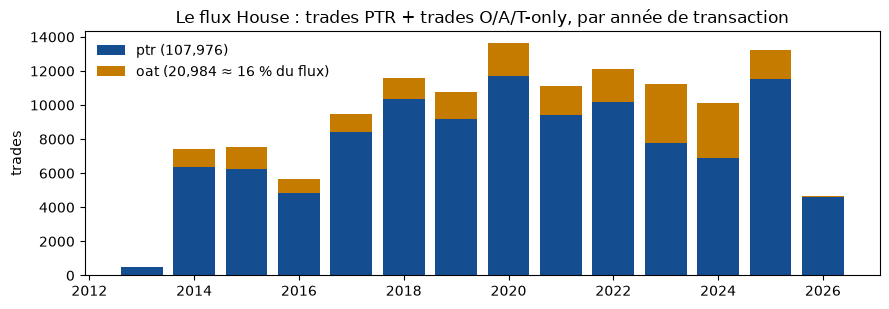

In [16]:
# Figure — le flux unifié par année (fig_10_flux)
_ct = pd.crosstab(df_uni["traded"].dt.year, df_uni["provenance"])
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(_ct.index, _ct["ptr"], color="#144d90", label=f"ptr ({_ct['ptr'].sum():,})")
ax.bar(_ct.index, _ct["oat"], bottom=_ct["ptr"], color="#c47b00",
       label=f"oat ({_ct['oat'].sum():,} ≈ {100*_ct['oat'].sum()/len(df_uni):.0f} % du flux)")
ax.set_title("Le flux House : trades PTR + trades O/A/T-only, par année de transaction")
ax.set_ylabel("trades"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## É3 — La population : qui trade, et qui a une photo

Sur les **900** personnes passées par la House (2014-2026), la plupart ne tradent pas d'actions
cotées. Puis, parmi les traders : ceux qui ont une **photo d'entrée** exploitable et les autres.

In [17]:
_traders_ptr = set(df["bioguide_id"])
_traders_uni = set(df_uni["bioguide_id"])
_oat_only    = _traders_uni - _traders_ptr
_photo_ok    = set(ph_ent["bioguide"])
G_PHOTO, G_ZERO = sorted(_traders_uni & _photo_ok), sorted(_traders_uni - _photo_ok)
cascade = pd.DataFrame([
    ("membres House 2014-2026 (registre v1)", len(reg14)),
    ("… qui TRADENT des actions cotées (PTR ∪ O/A/T)", len(_traders_uni)),
    ("        dont : vus par les PTR", len(_traders_ptr)),
    ("        dont : uniquement via O/A/T", len(_oat_only)),
    ("… qui ne tradent pas", len(reg14) - len(_traders_uni)),
    ("traders → G_photo (photo d'entrée exploitable)", len(G_PHOTO)),
    ("traders → G_zéro (sans photo exploitable)", len(G_ZERO)),
], columns=["population", "n"]).set_index("population")
display(cascade)
assert len(G_PHOTO) + len(G_ZERO) == len(_traders_uni)
assert len(_traders_ptr) + len(_oat_only) == len(_traders_uni)
print(f"partitions exactes : {len(G_PHOTO)} + {len(G_ZERO)} = {len(_traders_uni)} ✅  ·  "
      f"{len(reg14)} = {len(_traders_ptr)} + {len(_oat_only)} + {len(reg14)-len(_traders_uni)} ✅")

,n
population,
membres House 2014-2026 (registre v1),900
… qui TRADENT des actions cotées (PTR ∪ O/A/T),437
dont : vus par les PTR,305
dont : uniquement via O/A/T,132
… qui ne tradent pas,463
traders → G_photo (photo d'entrée exploitable),166
traders → G_zéro (sans photo exploitable),271


partitions exactes : 166 + 271 = 437 ✅  ·  900 = 305 + 132 + 463 ✅


In [18]:
# LIVRE DE COMPTES MEMBRES — d'où sortent les 424 (asserts)
_m16, _m_oat, _m_ptr = set(f16["bioguide"]), set(df_oat["bioguide_id"]), set(df["bioguide_id"])
_perdus = _m16 - _m_oat
livre_mb = pd.DataFrame([
    ("membres présents dans la table 16 brute", len(_m16), ""),
    ("− perdus par l'entonnoir (aucune ligne O/A/T exploitable)", -len(_perdus),
     f"dont {len(_perdus & _m_ptr)} repêchés par leurs PTR (restent dans la population), "
     f"{len(_perdus - _m_ptr)} vraiment sortis"),
    ("= membres avec ≥1 trade O/A/T exploitable", len(_m_oat), ""),
    ("   dont : ont AUSSI des PTR", len(_m_oat & _m_ptr), ""),
    ("   dont : oat SEULEMENT (invisibles avant)", len(_m_oat - _m_ptr), ""),
    ("membres PTR (rappel, non-régression vérifiée)", len(_m_ptr), ""),
    ("= UNION : la population qui trade", len(_m_ptr | _m_oat), ""),
], columns=["marche", "n", "note"]).set_index("marche")
display(livre_mb)
assert len(_m_ptr | _m_oat) == df_uni["bioguide_id"].nunique() == len(_traders_uni)
assert len(_m_oat - _m_ptr) == len(_oat_only)
assert len(df) == 107976 and len(_m_ptr) == 305, "NON-RÉGRESSION PTR cassée : l'univers étendu ne doit rien changer aux PTR"
print(f"✅ {len(_m_ptr)} (PTR) ∪ {len(_m_oat)} (oat) = {len(_m_ptr | _m_oat)} traders · "
      f"les {len(_perdus - _m_ptr)} vraiment sortis rejoignent les « ne tradent pas » de la cascade des 900")

,n,note
marche,,
membres présents dans la table 16 brute,370,
− perdus par l'entonnoir (aucune ligne O/A/T exploitable),-33,dont 15 repêchés par leurs PTR (restent dans l...
= membres avec ≥1 trade O/A/T exploitable,337,
dont : ont AUSSI des PTR,205,
dont : oat SEULEMENT (invisibles avant),132,
"membres PTR (rappel, non-régression vérifiée)",305,
= UNION : la population qui trade,437,


✅ 305 (PTR) ∪ 337 (oat) = 437 traders · les 18 vraiment sortis rejoignent les « ne tradent pas » de la cascade des 900


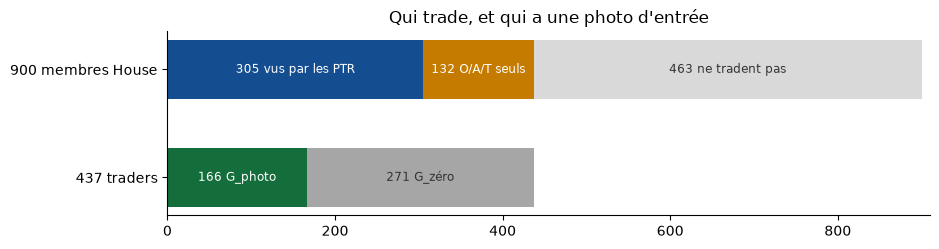

In [19]:
# Figure — la partition de la population, en deux barres (fig_10_partition)
fig, ax = plt.subplots(figsize=(9.5, 2.6))
_seg1 = [(len(_traders_ptr), "#144d90", f"{len(_traders_ptr)} vus par les PTR", "w"),
         (len(_oat_only), "#c47b00", f"{len(_oat_only)} O/A/T seuls", "w"),
         (len(reg14) - len(_traders_uni), "#d9d9d9", f"{len(reg14)-len(_traders_uni)} ne tradent pas", "#333333")]
_seg0 = [(len(G_PHOTO), "#146e3c", f"{len(G_PHOTO)} G_photo", "w"),
         (len(G_ZERO), "#a6a6a6", f"{len(G_ZERO)} G_zéro", "#333333")]
for _y, _segs in [(1, _seg1), (0, _seg0)]:
    _x = 0
    for _n, _c, _lab, _tc in _segs:
        ax.barh(_y, _n, left=_x, color=_c, height=0.55)
        ax.text(_x + _n / 2, _y, _lab, ha="center", va="center", fontsize=8.5, color=_tc)
        _x += _n
ax.set_yticks([1, 0]); ax.set_yticklabels([f"{len(reg14)} membres House", f"{len(_traders_uni)} traders"])
ax.set_xlim(0, 910)
for _sp in ("top", "right"):
    ax.spines[_sp].set_visible(False)
ax.set_title("Qui trade, et qui a une photo d'entrée")
plt.tight_layout(); plt.show()

## É4 — Les règles · G_zéro : le portefeuille se construit comme avant

Pour un membre sans photo, l'état h(m, i, t) (parts détenues du ticker i) part de 0 et suit ses
trades, exécutés au premier jour coté τ(t) ≥ date de transaction :

$$\text{achat : } h \mathrel{+}= \frac{\tilde v}{P(\tau(t))} \qquad\qquad
\text{vente : } h \mathrel{-}= \min\!\Big(\frac{\tilde v}{P(\tau(t))},\, h\Big)
\;\;\text{(pas de vente à découvert)}$$

### É4 (suite) · G_photo : on part du portefeuille d'entrée

Pour un membre avec photo déposée le jour f₀, chaque ligne tickérisée de la photo devient un
stock initial de parts, **au prix du jour du dépôt** (avant f₀, l'information n'existe pas) :

$$h_0(m, i) = \frac{\tilde v_i}{P_i(\tau(f_0))}$$

puis ses trades s'appliquent au fil de l'eau, mêmes règles qu'en É3. Conséquence : la vente
d'une position héritée n'est plus tronquée par min(q, h) — h₀ la couvre.

In [20]:
# h0_parts : une ligne par (membre, ticker) initialisable — q0 = mid / P(tau(f0))
def eff_price(tk, d):
    if tk not in prices: return None, None
    s = prices[tk]; pos = s.index.searchsorted(d)
    if pos >= len(s): return None, None
    p = s.iloc[pos]
    return (s.index[pos], p) if np.isfinite(p) and p > 0 else (None, None)

# h0 est construit pour TOUS les membres à photo exploitable (la restriction se fait PAR RUN,
# au moteur : la photo n'est injectée que si le membre a >= 1 trade dans le flux du run)
_rows, _v_ok = [], 0.0
for _r in ph_ent.itertuples():
    _t0, _p = eff_price(_r.ticker_y, _r.filing_date)
    if _t0 is None: continue
    _rows.append(dict(bioguide_id=_r.bioguide, ticker=_r.ticker_y, q0=_r.mid / _p, t0=_t0))
    _v_ok += _r.mid
h0_parts = pd.DataFrame(_rows)
_v_tot = float(ph_ent["mid"].sum())
_n_traders_photo = len(set(h0_parts["bioguide_id"]) & _traders_uni)
print(f"h₀ : {h0_parts['bioguide_id'].nunique()} membres initialisables (sur 248 à photo exploitable) · "
      f"{len(h0_parts):,} lignes · {_v_ok/_v_tot*100:.1f} % de la valeur convertie en parts")
print(f"     dont {_n_traders_photo} TRADENT (∈ {len(_traders_uni)}) → injectables ; les autres n'ont rien à simuler")
display(h0_parts.head(3))

h₀ : 228 membres initialisables (sur 248 à photo exploitable) · 7,797 lignes · 75.3 % de la valeur convertie en parts
     dont 160 TRADENT (∈ 437) → injectables ; les autres n'ont rien à simuler


,bioguide_id,ticker,q0,t0
0,A000148,ARAIX,546.522935,2021-07-29
1,A000148,CSVIX,273.082133,2021-07-29
2,A000148,CTTIX,4421.760486,2021-07-29


### É4.1 Validation — deux lignes recalculées à la main, hors moteur

In [21]:
for _bid in sorted(h0_parts["bioguide_id"].unique())[:2]:
    _l = h0_parts[h0_parts["bioguide_id"] == _bid].iloc[0]
    _src = ph_ent[(ph_ent["bioguide"] == _bid) & (ph_ent["ticker_y"] == _l["ticker"])].iloc[0]
    _t0, _p = eff_price(_l["ticker"], _src["filing_date"])
    assert abs(_l["q0"] - _src["mid"] / _p) < 1e-12 and _t0 == _l["t0"]
    print(f"{_bid} · {_l['ticker']:6s} : dépôt {_src['filing_date'].date()} → 1er coté {_t0.date()} · "
          f"ṽ = {_src['mid']:>9,.0f} $ ÷ P = {_p:8.2f} $ → q₀ = {_l['q0']:10.2f} ✅")

A000148 · ARAIX  : dépôt 2021-07-29 → 1er coté 2021-07-29 · ṽ =    32,500 $ ÷ P =    59.47 $ → q₀ =     546.52 ✅
A000373 · AA     : dépôt 2015-05-14 → 1er coté 2015-05-14 · ṽ =     8,000 $ ÷ P =    30.58 $ → q₀ =     261.64 ✅


In [22]:
# LIVRE DE COMPTES PHOTOS — d'où sortent les injectées (asserts)
_ph_tous, _ph_expl = set(e15["bioguide"]), set(ph_ent["bioguide"])
_ph_init = set(h0_parts["bioguide_id"])
_ph_inj  = _ph_init & set(df_uni["bioguide_id"])
livre_ph = pd.DataFrame([
    ("photos d'entrée déposées (1 par membre)", len(_ph_tous), "252 H + 32 C"),
    ("− sans aucune ligne tickérisée ET valorisée", -(len(_ph_tous) - len(_ph_expl)), "que du non-coté"),
    ("= photos exploitables", len(_ph_expl), ""),
    ("− aucun prix chargeable au 1er jour coté ≥ dépôt", -(len(_ph_expl) - len(_ph_init)), ""),
    ("= membres initialisables (h₀ construit)", len(_ph_init), ""),
    ("   dont : tradent (∈ population) → INJECTÉS", len(_ph_inj), "B injecte le sous-ensemble PTR"),
    ("   dont : aucun trade → rien à simuler", len(_ph_init - _ph_inj), ""),
], columns=["marche", "n", "note"]).set_index("marche")
display(livre_ph)
assert len(_ph_tous) - (len(_ph_tous) - len(_ph_expl)) - (len(_ph_expl) - len(_ph_init)) == len(_ph_init)
assert len(_ph_inj) + len(_ph_init - _ph_inj) == len(_ph_init)
print(f"✅ {len(_ph_tous)} → {len(_ph_expl)} → {len(_ph_init)} → {len(_ph_inj)} injectées "
      f"(+ {len(_ph_init - _ph_inj)} sans trade)")

,n,note
marche,,
photos d'entrée déposées (1 par membre),284,252 H + 32 C
− sans aucune ligne tickérisée ET valorisée,-36,que du non-coté
= photos exploitables,248,
− aucun prix chargeable au 1er jour coté ≥ dépôt,-20,
= membres initialisables (h₀ construit),228,
dont : tradent (∈ population) → INJECTÉS,160,B injecte le sous-ensemble PTR
dont : aucun trade → rien à simuler,68,


✅ 284 → 248 → 228 → 160 injectées (+ 68 sans trade)


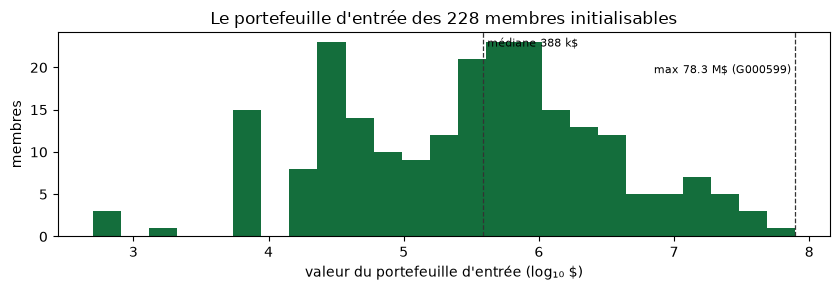

valeur h₀ : médiane 387,505 $ · max 78,321,726 $ (G000599)


In [23]:
# Figure — la valeur initialisée par membre (fig_10_h0_couverture)
_v0 = (h0_parts.assign(v=lambda d: [q * prices[t].loc[t0] for q, t, t0 in zip(d["q0"], d["ticker"], d["t0"])])
       .groupby("bioguide_id")["v"].sum())
fig, ax = plt.subplots(figsize=(8.5, 3.0))
ax.hist(np.log10(_v0.clip(lower=1)), bins=25, color="#146e3c")
ax.axvline(np.log10(_v0.median()), ls="--", c="#333333", lw=0.9)
ax.text(np.log10(_v0.median()), ax.get_ylim()[1] * 0.93, f" médiane {_v0.median()/1e3:,.0f} k$", fontsize=8, ha="left")
ax.axvline(np.log10(_v0.max()), ls="--", c="#333333", lw=0.9)
ax.text(np.log10(_v0.max()), ax.get_ylim()[1] * 0.80, f"max {_v0.max()/1e6:,.1f} M$ ({_v0.idxmax()}) ", fontsize=8, ha="right")
ax.set_xlabel("valeur du portefeuille d'entrée (log₁₀ $)"); ax.set_ylabel("membres")
ax.set_title(f"Le portefeuille d'entrée des {len(_v0)} membres initialisables")
plt.tight_layout(); plt.show()
print(f"valeur h₀ : médiane {_v0.median():,.0f} $ · max {_v0.max():,.0f} $ ({_v0.idxmax()})")

## É5 — Le moteur en parts, et les 4 runs

**Définition.** Pour un membre m : état h(m, i, t) = parts du ticker i (É3/É4). Chaque jour coté,
valeur et rendement se calculent sur les **parts de la veille** — ainsi une entrée de parts
(photo ou achat) ne compte qu'à partir du lendemain : *un apport n'est jamais une performance* :

$$r_m(t) = \frac{\sum_i h_i(t{-}1)\, P_i(t)}{\sum_i h_i(t{-}1)\, P_i(t{-}1)} - 1
\qquad\qquad \mathrm{NAV}_m(t) = \prod_{s \le t} \bigl(1 + r_m(s)\bigr)$$

Rendements bornés à ±50 %/jour (anti-données corrompues). On journalise la **masse tronquée** :
Σ (q − min(q, h))·P sur les ventes non couvertes.

In [24]:
def member_shares(g, h0_rows=None):
    """trades d'un membre (+ h0 éventuel) -> (N parts par jour, masse tronquée en $)."""
    _h0 = ({r.ticker: (r.t0, r.q0) for r in h0_rows.itertuples()}
           if h0_rows is not None and len(h0_rows) else {})
    cols, tronque = {}, 0.0
    for tk in sorted(set(g["ticker"]) | set(_h0)):
        gt = g[g["ticker"] == tk]
        h, events = 0.0, {}
        rows = ([(pd.Timestamp(_h0[tk][0]), "h0", _h0[tk][1], None)] if tk in _h0 else [])
        rows += [(row["traded"], row["op"], None, row["size_usd"])
                 for _, row in gt.sort_values("traded").iterrows()]
        for d, op, q0, usd in sorted(rows, key=lambda x: (x[0], 0 if x[1] == "h0" else 1)):
            if op == "h0":
                events[d] = h = h + q0                    # d = tau(f0), prix déjà consommé en É4
                continue
            dd, p = eff_price(tk, d)
            if dd is None: continue
            qty = usd / p
            if op == "buy":
                h = h + qty
            else:
                tronque += (qty - min(qty, h)) * p
                h = h - min(qty, h)
            events[dd] = h
        if events:
            cols[tk] = pd.Series(events).sort_index().reindex(cal).ffill().fillna(0.0)
    return (pd.DataFrame(cols) if cols else None), tronque

def daily_return(N):
    P = pd.DataFrame({tk: prices[tk] for tk in N.columns})
    Nsh = N.shift(1)
    num = (Nsh * P).sum(axis=1); den = (Nsh * P.shift(1)).sum(axis=1)
    r = pd.Series(np.where(den > 0, num / den - 1.0, 0.0), index=N.index).clip(-0.5, 0.5)
    active = N.sum(axis=1) > 0
    if not active.any(): return pd.Series(dtype=float)
    return r.loc[active.idxmax(): active[::-1].idxmax()]

**Les 4 runs** — même moteur, seules les données changent :

| run | flux | photo d'entrée |
|---|---|---|
| A (témoin) | ptr | non |
| B | ptr | oui |
| C | ptr ∪ oat | non |
| **D (la stratégie adaptée)** | **ptr ∪ oat** | **oui** |

In [25]:
def run_moteur(flux, use_h0):
    wfr, wft, tronq = {}, {}, {}
    _bids = set(flux["bioguide_id"])
    # la photo d'un membre n'est injectée que s'il a >= 1 trade dans CE flux (sinon rien à simuler)
    _h0g = ({b: g for b, g in h0_parts.groupby("bioguide_id") if b in _bids} if use_h0 else {})
    _fg = dict(tuple(flux.groupby("bioguide_id")))
    for bid in sorted(_bids):
        g = _fg.get(bid, flux.iloc[0:0])
        N, tr = member_shares(g, _h0g.get(bid))
        if N is None: continue
        r = daily_return(N)
        if len(r) < 2 or r.std() == 0: continue
        wfr[bid], tronq[bid] = r, tr
        wft[bid] = pd.to_datetime(np.sort(g["traded"].values))
    return wfr, wft, tronq, set(_h0g)

F_ptr = df_uni[df_uni["provenance"] == "ptr"]
runA = run_moteur(F_ptr, use_h0=False)
print(f"run A (témoin, ptr, départ zéro) : {len(runA[0])} membres avec série de rendement")

run A (témoin, ptr, départ zéro) : 226 membres avec série de rendement


In [26]:
runB = run_moteur(F_ptr, use_h0=True)
print(f"run B (+photo) : {len(runB[0])} membres | photos injectées : {len(runB[3])} | "
      f"tronqué {sum(runB[2].values())/1e6:,.0f} M$")

run B (+photo) : 257 membres | photos injectées : 117 | tronqué 897 M$


In [27]:
runC = run_moteur(df_uni, use_h0=False)
print(f"run C (+oat) : {len(runC[0])} membres | tronqué {sum(runC[2].values())/1e6:,.0f} M$")

run C (+oat) : 380 membres | tronqué 1,337 M$


In [28]:
runD = run_moteur(df_uni, use_h0=True)
print(f"run D (+photo +oat) : {len(runD[0])} membres | photos injectées : {len(runD[3])} "
      f"(les {len(runD[3]) - len(runB[3])} membres oat-only à photo sont enfin servis) | "
      f"tronqué {sum(runD[2].values())/1e6:,.0f} M$")

run D (+photo +oat) : 400 membres | photos injectées : 160 (les 43 membres oat-only à photo sont enfin servis) | tronqué 1,278 M$


In [29]:
RUNS = {"A (témoin)": runA, "B (+photo)": runB, "C (+oat)": runC, "D (adaptée)": runD}
recap6 = pd.DataFrame({k: dict(membres=len(r[0]), photos_injectees=len(r[3]),
                               tronque_MUSD=round(sum(r[2].values())/1e6))
                       for k, r in RUNS.items()}).T
display(recap6)

,membres,photos_injectees,tronque_MUSD
A (témoin),226,0,937
B (+photo),257,117,897
C (+oat),380,0,1337
D (adaptée),400,160,1278


### É5.1 Validation — trois preuves indépendantes
(i) **recalcul naïf** : la série d'un membre refaite en double boucle jours × tickers, sans le
moteur ; (ii) **un apport n'est jamais une performance** : membre synthétique à photo seule —
rendement nul le jour de l'injection ; (iii) **B ≡ A pour les membres sans photo**.

In [30]:
# (i) recalcul naïf du fil rouge (le membre à la plus grosse valeur initialisée)
FIL = _v0.loc[_v0.index.isin(runB[3])].idxmax()     # le plus gros h0 parmi les injectés de B
_g = F_ptr[F_ptr["bioguide_id"] == FIL]
N_fil, _ = member_shares(_g, h0_parts[h0_parts["bioguide_id"] == FIL])
r_moteur = runB[0][FIL]
_P = {tk: prices[tk] for tk in N_fil.columns}
_r_naif = {}
for _j in range(1, len(cal)):
    t0, t1 = cal[_j - 1], cal[_j]
    # np.nansum : un ticker sans prix ce jour-là est ignoré (même convention que le .sum() du moteur)
    num = np.nansum([N_fil[tk].iloc[_j - 1] * _P[tk].loc[t1] for tk in N_fil.columns])
    den = np.nansum([N_fil[tk].iloc[_j - 1] * _P[tk].loc[t0] for tk in N_fil.columns])
    if den > 0:
        _r_naif[t1] = max(min(num / den - 1.0, 0.5), -0.5)
_r_naif = pd.Series(_r_naif).reindex(r_moteur.index).fillna(0.0)
assert np.allclose(_r_naif.values, r_moteur.values, atol=1e-9)
print(f"(i) ✅ recalcul naïf de {FIL} : {len(r_moteur)} rendements identiques au moteur (atol 1e-9)")

(i) ✅ recalcul naïf de G000599 : 869 rendements identiques au moteur (atol 1e-9)


In [31]:
# (ii) apport ≠ performance : photo seule, zéro trade — r doit être nul le jour de l'injection
_h0_syn = h0_parts[h0_parts["bioguide_id"] == FIL].head(1)
N_syn, _ = member_shares(F_ptr.iloc[0:0], _h0_syn)
r_syn = daily_return(N_syn)
_t_inj = pd.Timestamp(_h0_syn["t0"].iloc[0])
assert abs(r_syn.loc[_t_inj]) < 1e-15
print(f"(ii) ✅ le jour de l'injection ({_t_inj.date()}), r = {r_syn.loc[_t_inj]:.0e} — l'apport ne crée rien ; "
      f"dès le lendemain, la position vit : r({r_syn.index[1].date()}) = {r_syn.iloc[1]*100:+.2f} %")

(ii) ✅ le jour de l'injection (2023-08-14), r = 0e+00 — l'apport ne crée rien ; dès le lendemain, la position vit : r(2023-08-15) = -0.79 %


In [32]:
# (iii) B ≡ A pour les membres sans photo (échantillon de 50)
_sans = [b for b in runA[0] if b not in runB[3]]
for _b in _sans[:50]:
    assert runB[0][_b].equals(runA[0][_b])
print(f"(iii) ✅ B ≡ A pour les membres sans photo injectée (contrôle sur 50/{len(_sans)})")

(iii) ✅ B ≡ A pour les membres sans photo injectée (contrôle sur 50/140)


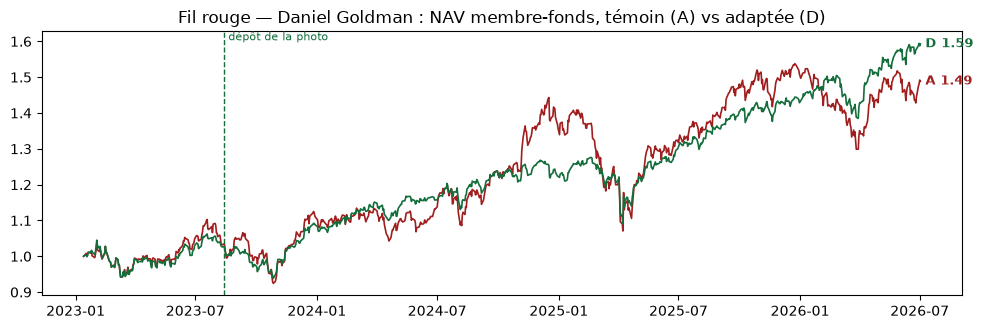

In [33]:
# Figure fil rouge — la NAV du membre, témoin vs adaptée (fig_10_filrouge)
_nom_fil = df.loc[df["bioguide_id"] == FIL, "name"].iloc[0] if (df["bioguide_id"] == FIL).any() else FIL
_f0 = h0_parts.loc[h0_parts["bioguide_id"] == FIL, "t0"].min()
fig, ax = plt.subplots(figsize=(10, 3.4))
for _lbl, _run, _c in [("A", runA, "#a01e1e"), ("D", runD, "#146e3c")]:
    if FIL in _run[0]:
        _nv = (1 + _run[0][FIL]).cumprod()
        ax.plot(_nv, color=_c, lw=1.2)
        ax.text(_nv.index[-1], _nv.iloc[-1], f" {_lbl} {_nv.iloc[-1]:.2f}", color=_c, fontsize=9, va="center", weight="bold")
ax.axvline(_f0, ls="--", c="#146e3c", lw=1.0)
ax.text(_f0, ax.get_ylim()[1], " dépôt de la photo", color="#146e3c", fontsize=8, va="top")
ax.set_title(f"Fil rouge — {_nom_fil} : NAV membre-fonds, témoin (A) vs adaptée (D)")
plt.tight_layout(); plt.show()

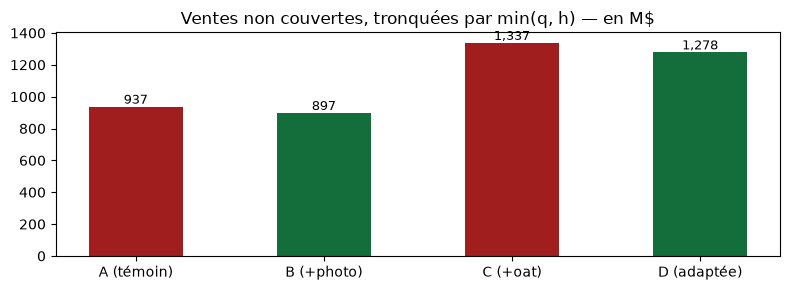

In [34]:
# Figure — la troncature des ventes fond quand la photo existe
_t_by = pd.DataFrame({k: pd.Series(r[2]) for k, r in RUNS.items()}).fillna(0.0)
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(4), _t_by.sum() / 1e6, color=["#a01e1e", "#146e3c", "#a01e1e", "#146e3c"],
       width=0.5, tick_label=list(RUNS))
for _i, _v in enumerate(_t_by.sum() / 1e6):
    ax.text(_i, _v, f"{_v:,.0f}", ha="center", va="bottom", fontsize=9)
ax.set_title("Ventes non couvertes, tronquées par min(q, h) — en M$")
plt.tight_layout(); plt.show()

## É6 — La stratégie : Sharpe · K walk-forward · deux poids

À chaque coupe (dernier jour coté de l'année Y, Y = 2015…2025), quatre gestes :

1. **noter** chaque membre sur son passé seulement :
   $\mathrm{Sharpe}_m(Y) = \dfrac{\overline{r_m}}{\sigma(r_m)}\sqrt{252}$ sur r_m(s), s ≤ 31/12/Y —
   **éligible si n_jours ≥ 126 et Sharpe > 0,4** (la règle du 05b Partie II : le minimum de trades saute) ;
2. **choisir K en marche avant** : $K^*(Y) = \arg\max_{K \in \{4..20\}} \sum_{y \le Y} x_y(K)$,
   où x_y(K) = l'excès annuel réalisé par le top-K l'année y déjà jouée (1ʳᵉ coupe : K = 10) —
   le K* est choisi sur le passé de LA stratégie jouée avec CE poids ;
3. **copier** les K* meilleurs en parts et **tenir un an** — deux poids joués partout :
   $w_k = 1/K^*$ (principal) et **inverse-vol** $w_k \propto 1/\hat\sigma_k$
   (σ̂_k = vol du membre sur son passé ≤ coupe) ;
4. **évaluer** par années civiles : $x_Y = \prod_{t\in Y}(1+r_{strat}) - \prod_{t\in Y}(1+r_{SPY})$,
   $t = \bar x / (\sigma(x)/\sqrt{n})$ (n = 11 ⇒ seuil t₁₀ ≈ 1,81), β et α par régression sur le SPY.

Nota : sans minimum de trades, un membre à photo et sans aucun trade PTR peut devenir éligible
(sa NAV = tenir son patrimoine) — c'est précisément ce que S1/S2 surveillent (É7).

In [35]:
def classement_sharpe(Y, wfr, min_days=126, min_sharpe=0.4):
    """Éligibles (n_jours ≥ 126 ET Sharpe > 0,4 — règle du 05b Partie II), classés par Sharpe décroissant."""
    yend = pd.Timestamp(f"{Y}-12-31")
    rows = []
    for bid, r in wfr.items():
        rr = r.loc[:yend]
        if len(rr) < min_days or rr.std() == 0:
            continue
        s = rr.mean() / rr.std() * np.sqrt(252)
        if s <= min_sharpe:
            continue
        rows.append((bid, s))
    rows.sort(key=lambda x: -x[1])
    return [b for b, _ in rows]

def yearly_excess(r):
    b = r_spy.reindex(r.index).fillna(0.0)
    return pd.Series({y: (1 + r[r.index.year == y]).prod() - (1 + b[b.index.year == y]).prod()
                      for y in sorted(set(r.index.year))})

def alpha_beta(r):
    d = pd.concat([r.rename("y"), r_spy.reindex(r.index).rename("x")], axis=1).dropna()
    if len(d) < 30 or d["x"].var() == 0:
        return dict(beta=np.nan, alpha_ann=np.nan, t_appr=np.nan)
    beta, alpha = np.polyfit(d["x"].values, d["y"].values, 1)
    eps = d["y"].values - (alpha + beta * d["x"].values)
    se = eps.std(ddof=2)
    appr = alpha / se * np.sqrt(252) if se > 0 else np.nan
    return dict(beta=beta, alpha_ann=(1 + alpha) ** 252 - 1, t_appr=appr * np.sqrt(len(d) / 252))

In [36]:
def strategie_kwf(wfr, poids="1/K", K_GRID=range(4, 21), K_INIT=10):
    """Sharpe · K walk-forward · poids ∈ {1/K, inv-vol}. Retourne r_strat, K*(Y), sélections, classements."""
    navk = pd.DataFrame({b: (1 + r.reindex(cal).fillna(0.0)).cumprod() for b, r in wfr.items()})
    cls = {Y: classement_sharpe(Y, wfr) for Y in range(2015, 2026)}
    def w_of(bids, Y):
        if poids == "1/K":
            return np.ones(len(bids)) / len(bids)
        yend = pd.Timestamp(f"{Y}-12-31")
        iv = np.array([1.0 / wfr[b].loc[:yend].std() for b in bids])
        return iv / iv.sum()
    def bloc(Y, K):                                    # rendements du bloc tenu l'année Y+1
        bids = cls[Y][:K]
        idx = cal[cal.year == Y + 1]
        if not bids or not len(idx): return None
        w = w_of(bids, Y)
        assert abs(w.sum() - 1.0) < 1e-9               # autofinancement : les poids somment à 1
        tR = cal[cal.get_loc(idx[0]) - 1]
        nbr = pd.Series(w / navk.loc[tR, bids].values, index=bids)
        nav = navk.loc[idx, bids].mul(nbr, axis=1).sum(axis=1)
        r = nav / nav.shift(1) - 1
        r.iloc[0] = nav.iloc[0] - 1.0
        return r
    xs = {(K, Y + 1): yearly_excess(b).iloc[0]
          for K in K_GRID for Y in range(2015, 2026) if (b := bloc(Y, K)) is not None}
    rets, kpath, sels = [], {}, {}
    for Y in range(2015, 2026):
        deja = [y for y in range(2016, Y + 1)]         # années tenues, terminées à la coupe 31/12/Y
        K = K_INIT if not deja else max(K_GRID, key=lambda k: sum(xs.get((k, y), 0.0) for y in deja))
        b = bloc(Y, K)
        if b is None: continue
        kpath[Y + 1], sels[Y + 1] = K, cls[Y][:K]
        rets.append(b)
    if not rets:
        return dict(r=pd.Series(dtype=float), kpath=kpath, sels=sels, xs=xs, cls=cls)
    return dict(r=pd.concat(rets).sort_index(), kpath=kpath, sels=sels, xs=xs, cls=cls)

In [37]:
# LE tableau du notebook : 4 runs × 2 poids
def ligne(r):
    e = yearly_excess(r); n = len(e)
    if n < 2: return dict(exces_an=np.nan, t=np.nan, gagnantes=f"-/{n}", beta=np.nan,
                          alpha_ann=np.nan, t_appr=np.nan)
    ab = alpha_beta(r)
    return dict(exces_an=e.mean(), t=e.mean() / e.std(ddof=1) * np.sqrt(n),
                gagnantes=f"{int((e > 0).sum())}/{n}", **ab)

POIDS = ["1/K", "inv-vol"]
strat = {(k, p): strategie_kwf(r[0], poids=p) for k, r in RUNS.items() for p in POIDS}
tab7 = pd.DataFrame({f"{k} · {p}": ligne(s["r"]) for (k, p), s in strat.items()}).T
print(f"Sharpe (éligible : n_jours ≥ 126 et Sharpe > 0,4) · K walk-forward (4-20, départ 10) — "
      f"{len(yearly_excess(strat[('A (témoin)', '1/K')]['r']))} années civiles, seuil t₁₀ ≈ 1,81")
display(tab7.round(3))

Sharpe (éligible : n_jours ≥ 126 et Sharpe > 0,4) · K walk-forward (4-20, départ 10) — 11 années civiles, seuil t₁₀ ≈ 1,81


,exces_an,t,gagnantes,beta,alpha_ann,t_appr
A (témoin) · 1/K,0.008574,0.365653,4/11,0.988663,0.006169,0.283756
A (témoin) · inv-vol,-0.002704,-0.113275,4/11,1.001319,-0.005213,-0.271197
B (+photo) · 1/K,0.065882,0.845824,5/11,0.976797,0.051725,1.546512
B (+photo) · inv-vol,0.030584,0.598159,5/11,0.932131,0.032976,1.330373
C (+oat) · 1/K,-0.012978,-0.774721,3/11,0.82757,0.009941,0.65485
C (+oat) · inv-vol,-0.027615,-1.378056,5/11,0.661261,0.019546,1.059313
D (adaptée) · 1/K,-0.015595,-0.608057,6/11,0.846126,0.006097,0.368239
D (adaptée) · inv-vol,-0.025664,-1.286074,3/11,0.743109,0.010526,0.696709


In [38]:
# Le chemin K*(Y) et le nombre d'éligibles par coupe
kpaths = pd.DataFrame({f"{k} · {p}": s["kpath"] for (k, p), s in strat.items()}).T
kpaths.index.name = "K* pour l'année tenue →"
display(kpaths)
elig7 = pd.DataFrame({k: {Y: len(strat[(k, "1/K")]["cls"][Y]) for Y in range(2015, 2026)}
                      for k in RUNS}).T
elig7.index.name = "éligibles à la coupe →"
display(elig7)

,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
K* pour l'année tenue →,,,,,,,,,,,
A (témoin) · 1/K,10,4,4,4,13,12,4,5,5,4,4
A (témoin) · inv-vol,10,4,4,4,4,12,4,12,4,4,4
B (+photo) · 1/K,10,4,4,4,4,4,4,4,4,4,4
B (+photo) · inv-vol,10,4,4,4,4,4,4,4,4,4,4
C (+oat) · 1/K,10,18,8,4,8,11,12,12,11,11,11
C (+oat) · inv-vol,10,20,5,6,6,11,12,12,11,11,11
D (adaptée) · 1/K,10,18,4,4,6,4,11,11,11,11,11
D (adaptée) · inv-vol,10,20,5,5,6,6,11,11,9,11,11


,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
éligibles à la coupe →,,,,,,,,,,,
A (témoin),42,61,92,76,123,128,152,121,152,174,184
B (+photo),43,67,104,81,140,142,170,137,173,199,216
C (+oat),51,82,135,101,179,186,227,163,243,289,321
D (adaptée),52,88,143,106,193,199,241,177,256,306,338


### É6.1 Validation — le bloc 2018 (K = 10, poids 1/K) recalculé à la main
Sans le moteur de stratégie : sélection re-classée, parts recomptées, excès annuel recoupé.
(Les poids de chaque bloc somment à 1 — asserté dans le moteur : autofinancement.)

In [39]:
_s = strat[("A (témoin)", "1/K")]
_wfr = RUNS["A (témoin)"][0]
_navk = pd.DataFrame({b: (1 + r.reindex(cal).fillna(0.0)).cumprod() for b, r in _wfr.items()})
_bids = classement_sharpe(2017, _wfr)[:10]
_idx = cal[cal.year == 2018]; _tR = cal[cal.get_loc(_idx[0]) - 1]
_nbr = {b: (1.0 / len(_bids)) / _navk.loc[_tR, b] for b in _bids}
_nav_fin = sum(_nbr[b] * _navk.loc[_idx[-1], b] for b in _bids)
_spy_2018 = (1 + r_spy[r_spy.index.year == 2018].fillna(0)).prod()
_x_main = (_nav_fin - 1.0) - (_spy_2018 - 1.0)
assert abs(_x_main - _s["xs"][(10, 2018)]) < 1e-12
print(f"✅ bloc 2018, K=10 : excès recalculé à la main = {_x_main*100:+.2f} % ≡ moteur "
      f"({_s['xs'][(10, 2018)]*100:+.2f} %)")

✅ bloc 2018, K=10 : excès recalculé à la main = -3.20 % ≡ moteur (-3.20 %)


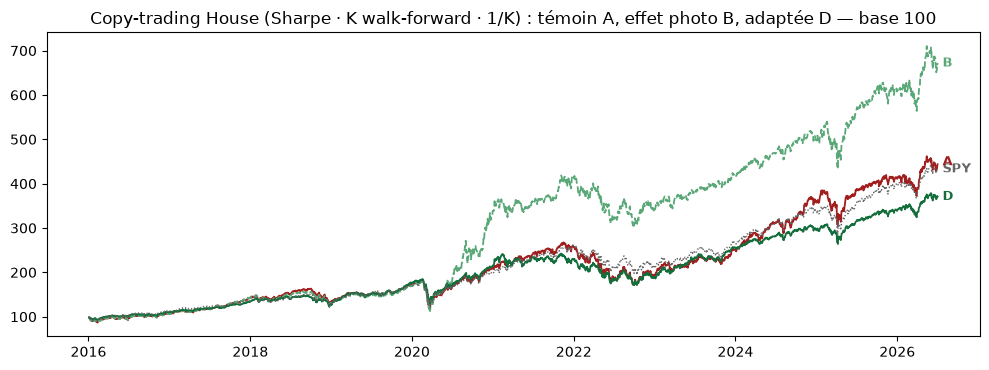

In [40]:
# Figure — NAV de la stratégie (poids 1/K) : A, B, D, SPY — base 100 (fig_10_nav)
_rs9 = {"A": ("A (témoin)", "#a01e1e", "-"), "B": ("B (+photo)", "#5aa878", "--"),
        "D": ("D (adaptée)", "#146e3c", "-")}
_i0 = max(strat[(v[0], "1/K")]["r"].index[0] for v in _rs9.values())
fig, ax = plt.subplots(figsize=(10, 3.8))
_fins = []
for _k, (_lbl, _c, _ls) in _rs9.items():
    _r = strat[(_lbl, "1/K")]["r"]
    _n = (1 + _r[_r.index >= _i0]).cumprod() * 100
    ax.plot(_n, color=_c, lw=1.3, ls=_ls)
    _fins.append([_k, _c, _n.index[-1], float(_n.iloc[-1])])
_spy_n = (1 + r_spy[r_spy.index >= _i0].fillna(0)).cumprod() * 100
ax.plot(_spy_n, color="#666666", lw=1.0, ls=":")
_fins.append(["SPY", "#666666", _spy_n.index[-1], float(_spy_n.iloc[-1])])
_fins.sort(key=lambda f: f[3])
for _j in range(1, len(_fins)):
    if _fins[_j][3] - _fins[_j - 1][3] < 16:
        _fins[_j][3] = _fins[_j - 1][3] + 16
for _k, _c, _xf, _yf in _fins:
    ax.text(_xf, _yf, f" {_k}", color=_c, fontsize=9.5, va="center", weight="bold")
ax.set_title("Copy-trading House (Sharpe · K walk-forward · 1/K) : témoin A, effet photo B, adaptée D — base 100")
plt.tight_layout(); plt.show()

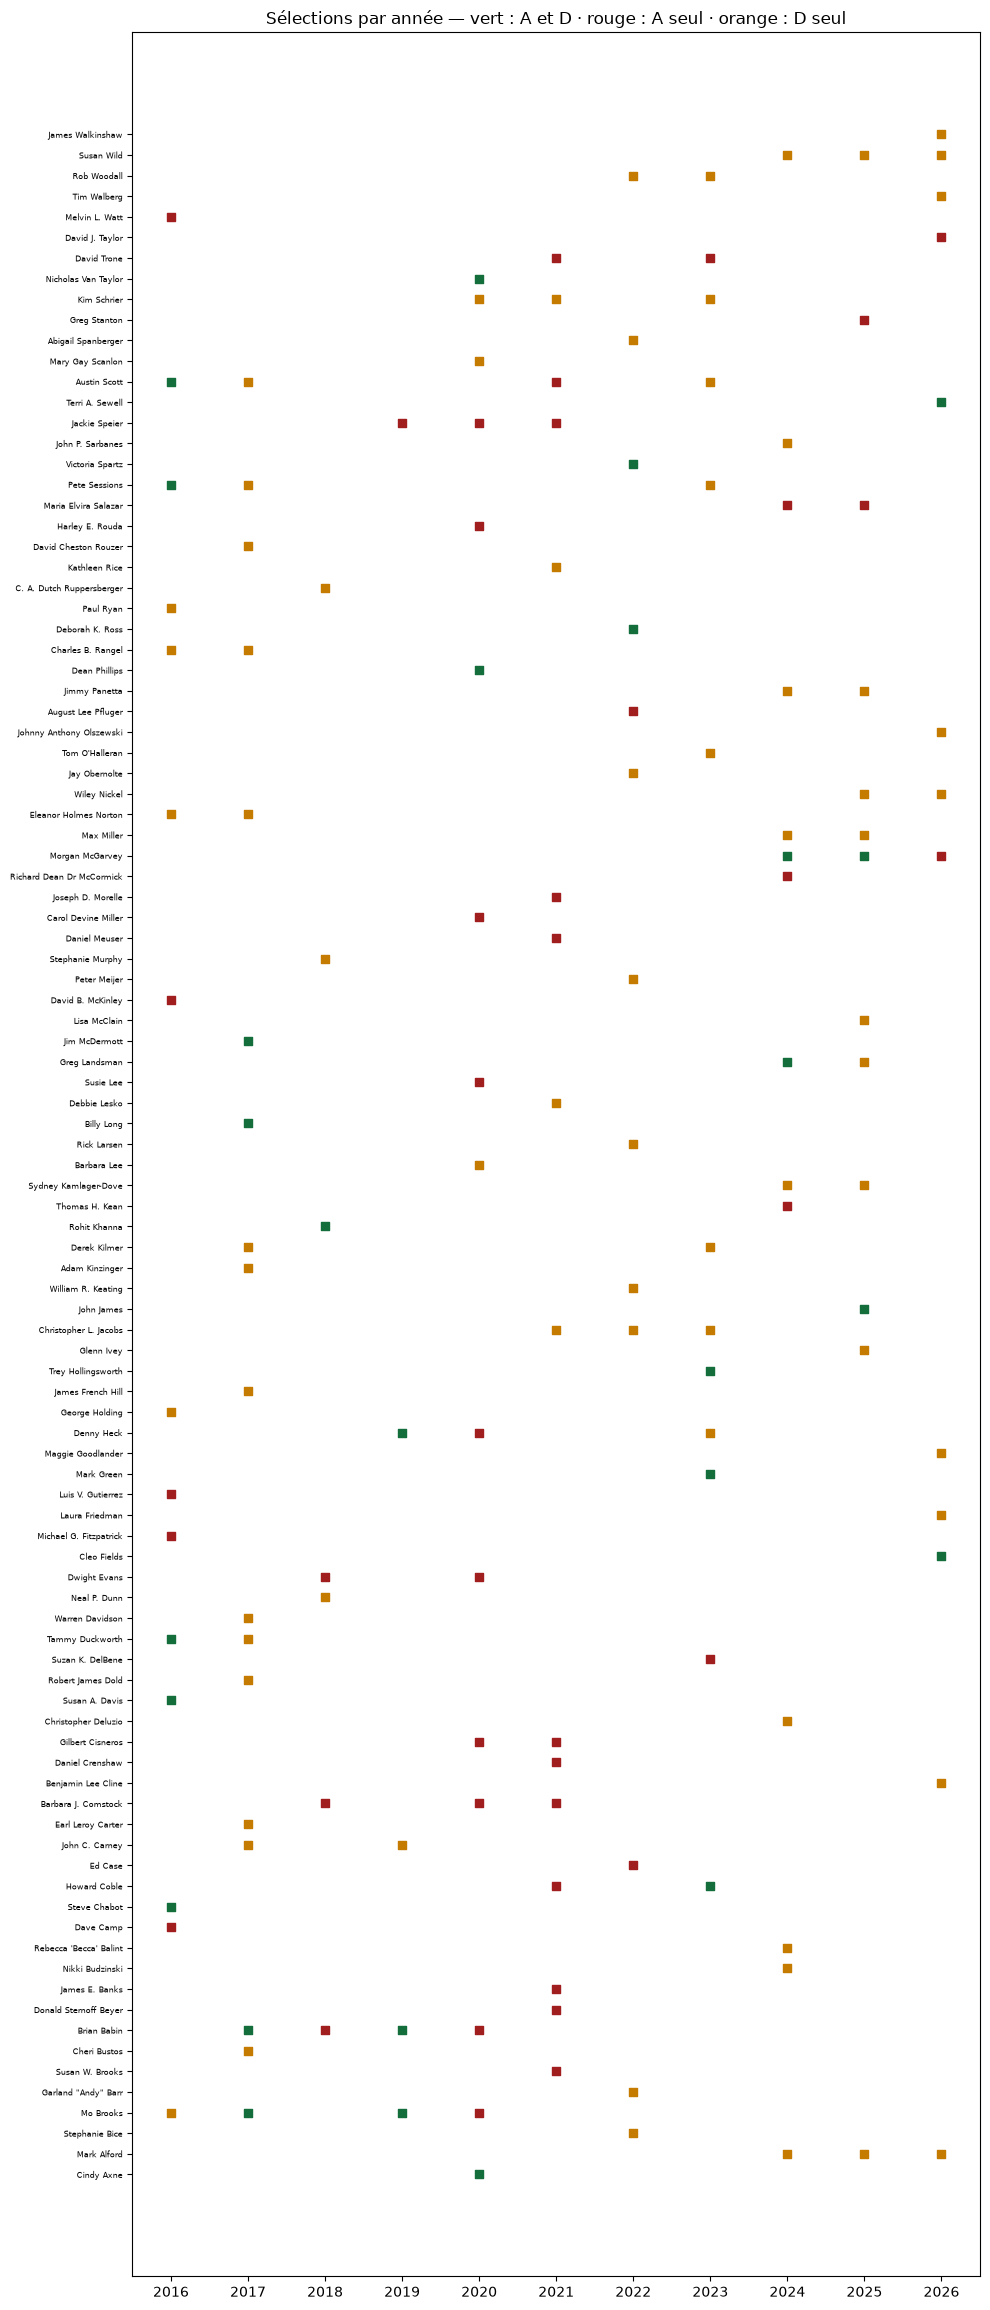

années où la sélection change entre A et D : 11/11


In [41]:
# Figure — qui est copié : les sélections A vs D (poids 1/K), année par année
_ans = sorted(set(strat[("A (témoin)", "1/K")]["sels"]) | set(strat[("D (adaptée)", "1/K")]["sels"]))
_selA = strat[("A (témoin)", "1/K")]["sels"]; _selD = strat[("D (adaptée)", "1/K")]["sels"]
_tous = sorted({b for a in _ans for b in _selA.get(a, []) + _selD.get(a, [])})
NOMS = dict(df_uni.drop_duplicates("bioguide_id")[["bioguide_id", "name"]].values)
fig, ax = plt.subplots(figsize=(10, 0.22 * len(_tous) + 1.2))
for yi, b in enumerate(_tous):
    for xi, an in enumerate(_ans):
        inA, inD = b in _selA.get(an, []), b in _selD.get(an, [])
        c = "#146e3c" if (inA and inD) else ("#a01e1e" if inA else ("#c47b00" if inD else None))
        if c:
            ax.scatter(xi, yi, s=40, marker="s", color=c)
ax.set_xticks(range(len(_ans))); ax.set_xticklabels(_ans)
ax.set_yticks(range(len(_tous)))
ax.set_yticklabels([NOMS.get(b, b) for b in _tous], fontsize=6)
ax.set_title("Sélections par année — vert : A et D · rouge : A seul · orange : D seul")
plt.tight_layout(); plt.show()
print(f"années où la sélection change entre A et D : "
      f"{sum(set(_selA.get(a, [])) != set(_selD.get(a, [])) for a in _ans)}/{len(_ans)}")

## É7 — Le mélange G_photo / G_zéro : surveillé (S1), contrôlé (S2)

Le Sharpe des deux groupes n'est pas mesuré pareil (G_zéro : petite base bruitée ; G_photo :
portefeuille complet dès le dépôt, plus lisse). Ce n'est pas une triche — mais on le surveille :
**S1** = part de G_photo dans les éligibles vs dans le top-K, à chaque coupe ;
**S2** = la même stratégie jouée dans chaque groupe séparément (A et D, poids 1/K).

,part_eligibles,part_topK
annee,,
2016,10%,10%
2017,14%,28%
2018,20%,50%
2019,15%,0%
2020,29%,67%
2021,32%,50%
2022,35%,55%
2023,32%,36%
2024,36%,64%


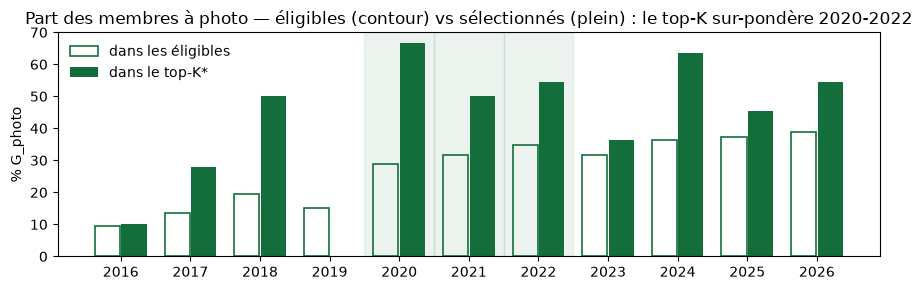

In [42]:
# S1 — le top-K sur-représente-t-il un groupe ? (run D, poids 1/K) — fig_10_s1
_SET_PHOTO = runD[3]                       # référentiel : les photos RÉELLEMENT injectées dans D
_sD = strat[("D (adaptée)", "1/K")]
_s1 = pd.DataFrame([dict(annee=Y + 1,
                         part_eligibles=np.mean([b in _SET_PHOTO for b in _sD["cls"][Y]]),
                         part_topK=np.mean([b in _SET_PHOTO for b in _sD["sels"].get(Y + 1, [np.nan])]))
                    for Y in range(2015, 2026) if _sD["cls"][Y] and (Y + 1) in _sD["sels"]]
                   ).set_index("annee")
display(_s1.style.format("{:.0%}"))
_x = np.arange(len(_s1))
fig, ax = plt.subplots(figsize=(9, 3))
for _i, _an in enumerate(_s1.index):
    if _an in (2020, 2021, 2022):
        ax.axvspan(_i - 0.5, _i + 0.5, color="#146e3c", alpha=0.08, zorder=0)
ax.bar(_x - 0.19, _s1["part_eligibles"] * 100, width=0.36, facecolor="none",
       edgecolor="#146e3c", lw=1.2, label="dans les éligibles")
ax.bar(_x + 0.19, _s1["part_topK"] * 100, width=0.36, color="#146e3c", label="dans le top-K*")
ax.set_xticks(_x); ax.set_xticklabels(_s1.index)
ax.set_ylabel("% G_photo"); ax.legend(frameon=False)
ax.set_title("Part des membres à photo — éligibles (contour) vs sélectionnés (plein) : le top-K sur-pondère 2020-2022")
plt.tight_layout(); plt.show()

In [43]:
# S2 — contrôle stratifié : la même stratégie dans chaque groupe séparément (poids 1/K)
_s2 = {}
for _k in ["A (témoin)", "D (adaptée)"]:
    for _grp, _dans in [("G_photo", True), ("G_zéro", False)]:
        _wfr_g = {b: r for b, r in RUNS[_k][0].items() if (b in _SET_PHOTO) == _dans}
        _s2[f"{_k} · {_grp}"] = ligne(strategie_kwf(_wfr_g, poids="1/K")["r"])
tab_s2 = pd.DataFrame(_s2).T
print("S2 — verdicts par strate (à comparer aux lignes mixtes de É7) :")
display(tab_s2.round(3))

S2 — verdicts par strate (à comparer aux lignes mixtes de É7) :


,exces_an,t,gagnantes,beta,alpha_ann,t_appr
A (témoin) · G_photo,0.003843,0.116922,5/11,1.09109,-0.008914,-0.293879
A (témoin) · G_zéro,-0.009675,-0.459034,4/11,0.961214,-0.005938,-0.261373
D (adaptée) · G_photo,-0.011296,-0.701876,3/11,0.937714,-0.000906,-0.0482
D (adaptée) · G_zéro,-0.00795,-0.365886,3/11,0.853539,0.009193,0.585951


## É8 — Lecture

In [44]:
_dA, _dD = tab7.loc["A (témoin) · 1/K"], tab7.loc["D (adaptée) · 1/K"]
_best = tab7["t"].astype(float).idxmax()
print("Synthèse (Sharpe · K walk-forward, House) :")
print(f"  poids 1/K     : excès {_dA['exces_an']*100:+.1f} % (A) → {_dD['exces_an']*100:+.1f} % (D) | "
      f"t {_dA['t']:.2f} → {_dD['t']:.2f} | β {_dA['beta']:.2f} → {_dD['beta']:.2f} | "
      f"t_appr {_dA['t_appr']:.2f} → {_dD['t_appr']:.2f}")
_iA, _iD = tab7.loc["A (témoin) · inv-vol"], tab7.loc["D (adaptée) · inv-vol"]
print(f"  poids inv-vol : excès {_iA['exces_an']*100:+.1f} % (A) → {_iD['exces_an']*100:+.1f} % (D) | "
      f"t {_iA['t']:.2f} → {_iD['t']:.2f} | β {_iA['beta']:.2f} → {_iD['beta']:.2f} | "
      f"t_appr {_iA['t_appr']:.2f} → {_iD['t_appr']:.2f}")
print(f"  meilleure ligne du tableau : {_best} (t = {tab7.loc[_best, 't']:.2f}) — seuil t₁₀ ≈ 1,81")
print(f"  S2 (strates)  : " + " | ".join(f"{k} t={v['t']:.2f}" for k, v in tab_s2.round(2).iterrows()))

Synthèse (Sharpe · K walk-forward, House) :
  poids 1/K     : excès +0.9 % (A) → -1.6 % (D) | t 0.37 → -0.61 | β 0.99 → 0.85 | t_appr 0.28 → 0.37
  poids inv-vol : excès -0.3 % (A) → -2.6 % (D) | t -0.11 → -1.29 | β 1.00 → 0.74 | t_appr -0.27 → 0.70
  meilleure ligne du tableau : B (+photo) · 1/K (t = 0.85) — seuil t₁₀ ≈ 1,81
  S2 (strates)  : A (témoin) · G_photo t=0.12 | A (témoin) · G_zéro t=-0.46 | D (adaptée) · G_photo t=-0.70 | D (adaptée) · G_zéro t=-0.37


**À retenir, indépendamment des chiffres ci-dessus** :
- B − A = l'effet photo seul ; C − A = l'effet O/A/T seul ; D = la stratégie adaptée ;
- éligibilité du 05b Partie II (n_jours ≥ 126 et Sharpe > 0,4, sans minimum de trades) : un membre
  à photo sans aucun trade PTR peut être éligible — S1/S2 surveillent ce que ça fait au classement ;
- les O/A/T entrent à leur **date de transaction** (convention du moteur) alors qu'ils sont
  divulgués ~374 j après — caveat de jouabilité, assumé ;
- un achat PTR antérieur au dépôt de la photo peut être compté deux fois (h₀ + flux) : non
  réconciliable en fourchettes, assumé ;
- le non-coté (fonds, LLC, immobilier) reste hors périmètre, comme partout dans le projet.

## É9 — Compléments de présentation (fiche chercheur)

Trois objets : les **effets appariés** (les runs partagent les mêmes années et le même SPY,
donc chaque effet se teste en différences année par année : $d_Y = x_Y(\text{run}) - x_Y(A)$,
$t = \bar d / (\sigma_d/\sqrt{n})$) ; le **déplacement des Sharpe** membre par membre (coupe 2021) ;
la **puissance** du test (quel excès moyen est détectable à n = 11 ?).

In [45]:
# Effets appariés année par année (poids 1/K) : photo (B−A), oat (C−A), interaction
X9 = pd.DataFrame({k.split(" ")[0]: yearly_excess(strat[(k, "1/K")]["r"]) for k in RUNS})
display(X9.round(4))
_eff = {"photo (B−A)": X9["B"] - X9["A"], "oat (C−A)": X9["C"] - X9["A"],
        "interaction (D−B−C+A)": X9["D"] - X9["B"] - X9["C"] + X9["A"]}
tab_eff = pd.DataFrame({n: {"moy_pct_an": 100 * d.mean(),
                            "t_apparie": d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))}
                        for n, d in _eff.items()}).T
display(tab_eff.round(2))

,A,B,C,D
2016,-0.0630,-0.0630,-0.0268,-0.0268
2017,0.1258,0.1258,0.0300,0.0042
2018,-0.0069,-0.0289,-0.0047,0.0123
2019,-0.0276,-0.0276,0.0495,0.0495
2020,0.0338,0.8250,-0.0755,0.0435
2021,-0.0645,-0.0668,-0.0756,-0.2249
2022,-0.0631,0.0145,-0.0063,0.0086
2023,0.0339,-0.0348,0.0958,0.0922
2024,0.1709,-0.0716,-0.0801,-0.0986
2025,-0.0267,0.0445,-0.0385,-0.0299


,moy_pct_an,t_apparie
photo (B−A),5.73,0.74
oat (C−A),-2.16,-0.74
interaction (D−B−C+A),-5.99,-0.89


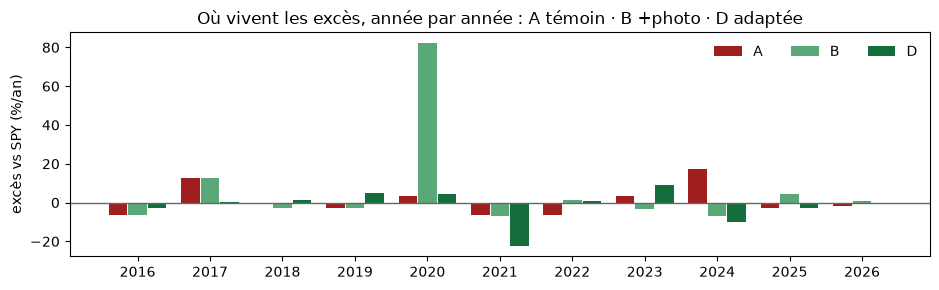

In [46]:
# Figure — l'excès annuel vs SPY, année par année (fig_10_exces_annuel)
_xa = np.arange(len(X9)); _w = 0.27
fig, ax = plt.subplots(figsize=(9.5, 3.0))
for _off, _k, _c in [(-_w, "A", "#a01e1e"), (0.0, "B", "#5aa878"), (_w, "D", "#146e3c")]:
    ax.bar(_xa + _off, 100 * X9[_k], _w * 0.95, color=_c, label=_k)
ax.axhline(0, color="#666666", lw=1)
ax.set_xticks(_xa); ax.set_xticklabels(X9.index)
ax.set_ylabel("excès vs SPY (%/an)"); ax.legend(frameon=False, ncol=3)
ax.set_title("Où vivent les excès, année par année : A témoin · B +photo · D adaptée")
plt.tight_layout(); plt.show()

In [47]:
# Puissance : excès annuel moyen minimal détectable (MDE) avec n = 11 années
import scipy.stats as _st
_sig = X9["D"].std(ddof=1)
_t_crit, _t_pow = _st.t.ppf(0.95, df=len(X9) - 1), _st.t.ppf(0.80, df=len(X9) - 1)
MDE80 = (_t_crit + _t_pow) * _sig / np.sqrt(len(X9))
print(f"σ̂ des excès annuels (D) = {_sig*100:.1f} %/an")
print(f"MDE (α = 5 % unilatéral, puissance 80 %) = ({_t_crit:.2f} + {_t_pow:.2f}) × σ̂/√{len(X9)} = {MDE80*100:.1f} %/an")
print("→ sous ce niveau, un vrai excès resterait probablement indétecté : le t faible borne ce qu'on peut voir, il ne prouve pas l'absence d'effet")

σ̂ des excès annuels (D) = 8.5 %/an
MDE (α = 5 % unilatéral, puissance 80 %) = (1.81 + 0.88) × σ̂/√11 = 6.9 %/an
→ sous ce niveau, un vrai excès resterait probablement indétecté : le t faible borne ce qu'on peut voir, il ne prouve pas l'absence d'effet


,A,D,photo
A000055,NaN,0.679083,False
A000148,NaN,1.104779,True
A000367,0.839852,0.810734,False


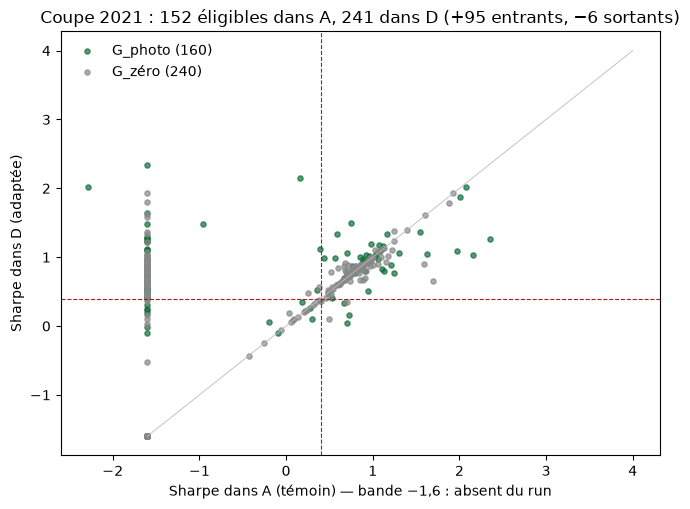

éligibles (Sharpe > 0,4 et n ≥ 126 j) à la coupe 2021 : A 152 · D 241 · entrants 95 · sortants 6


In [48]:
# Le déplacement des Sharpe : A (témoin) vs D (adaptée), coupe 31/12/2021 (fig_10_sharpe_shift)
_yend9 = pd.Timestamp("2021-12-31")
def _sharpe_au(r, yend):
    rr = r.loc[:yend]
    return rr.mean() / rr.std() * np.sqrt(252) if len(rr) >= 126 and rr.std() > 0 else np.nan
sh9 = pd.DataFrame({"A": pd.Series({b: _sharpe_au(r, _yend9) for b, r in runA[0].items()}),
                    "D": pd.Series({b: _sharpe_au(r, _yend9) for b, r in runD[0].items()})})
sh9["photo"] = sh9.index.isin(runD[3])
display(sh9.head(3))
_ABS = -1.6                                        # bande « absent de ce run »
_x9, _y9 = sh9["A"].fillna(_ABS), sh9["D"].fillna(_ABS)
fig, ax = plt.subplots(figsize=(6.8, 5.2))
for _g, _c, _lab in [(True, "#146e3c", f"G_photo ({int(sh9['photo'].sum())})"),
                     (False, "#888888", f"G_zéro ({int((~sh9['photo']).sum())})")]:
    _m = sh9["photo"] == _g
    ax.scatter(_x9[_m], _y9[_m], s=14, color=_c, alpha=0.7, label=_lab)
ax.axhline(0.4, ls="--", c="#a01e1e", lw=0.8); ax.axvline(0.4, ls="--", c="#a01e1e", lw=0.8)
ax.plot([_ABS, 4], [_ABS, 4], lw=0.6, c="#bbbbbb")
ax.set_xlabel("Sharpe dans A (témoin) — bande −1,6 : absent du run"); ax.set_ylabel("Sharpe dans D (adaptée)")
_el_A, _el_D = int((sh9["A"] > 0.4).sum()), int((sh9["D"] > 0.4).sum())
_nouv = int(((sh9["D"] > 0.4) & ~(sh9["A"] > 0.4)).sum()); _sort = int(((sh9["A"] > 0.4) & ~(sh9["D"] > 0.4)).sum())
ax.set_title(f"Coupe 2021 : {_el_A} éligibles dans A, {_el_D} dans D (+{_nouv} entrants, −{_sort} sortants)")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()
print(f"éligibles (Sharpe > 0,4 et n ≥ 126 j) à la coupe 2021 : A {_el_A} · D {_el_D} · entrants {_nouv} · sortants {_sort}")

In [49]:
# Garde-fou final : prices_v2 n'a pas bougé
assert sorted(os.listdir(PRICES_V2)) == _SNAP_PV2, "prices_v2 modifié — INTERDIT"
print(f"✅ prices_v2 intact ({len(_SNAP_PV2)} fichiers)")

✅ prices_v2 intact (3351 fichiers)
